In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

## Input file and parameter suffix for output
seed = '98765'
suffix = '2-100'
filename = f'processed_data/abm_seed_{seed}_{suffix}.csv'

In [3]:
## Load data
df = pd.read_csv(filename)
df.head()

,time,site1,site2,proportion_site1,proportion_site2,magnetization
0,0.0,0,100,0.0,1.0,-1.0
1,0.5,0,100,0.0,1.0,-1.0
2,1.0,0,100,0.0,1.0,-1.0
3,1.5,0,100,0.0,1.0,-1.0
4,2.0,0,100,0.0,1.0,-1.0


/var/folders/ng/l4j590g95vl5r33ctw59y6cr0000gn/T/ipykernel_96489/4249867916.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['time'] = df_plot['time'] - tmin


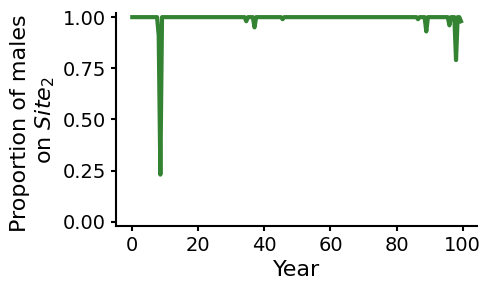

In [4]:
fig, ax = plt.subplots(figsize=(5, 3))

## Subset dataframe to plot
tmin = 30
tmax = 80
df_plot = df.loc[(df['time'] > tmin) & (df['time'] < tmax), :]
df_plot['time'] = df_plot['time'] - tmin
df_plot = df

## Plot the two sites over time
ax.plot(df_plot['time'], df_plot['proportion_site2'], color='darkgreen', linewidth=3, alpha=0.8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=14, width=1.5)

ax.set_ylim(-0.02,1.02)
ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('Proportion of males \non $Site_{2}$', fontsize=16)

plt.tight_layout()
plt.savefig(out_dir/f'abm_param_scan_{suffix}.png', dpi=300)